In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from netCDF4 import Dataset
from numpy.fft import fft, fftfreq
from scipy.interpolate import RegularGridInterpolator
from sklearn.decomposition import PCA
from scipy.linalg import logm, expm
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from matplotlib.gridspec import GridSpec
from scipy.stats import linregress
from matplotlib.colors import ListedColormap

In [2]:
file_path = "/work/DATA/Reforecast/S2S/ECMWF/z/z_202012_ens01.nc"
nc = Dataset(file_path)
lat_ = nc.variables["latitude"][:61]  # n_lat = 61 # NH
lon_ = nc.variables["longitude"][:]
lat0 = nc.variables["latitude"][60]
lon180 = nc.variables["longitude"][120]
lat_[30]

45.0

In [3]:
n_mb = [f"{i:02}" for i in range(1, 11)]
n_mth_w = ["10", "11", "12", "01", "02"]    # n_mth = 5 # winter

yr_rf = np.arange(2001, 2021).astype(str)   # Year of reforecast data
yr_ra = np.arange(1979, 2022).astype(str)  # Year of reanalysis data
yr_ra1 = np.arange(1979, 2021).astype(str)  # Year of reanalysis data
yr_ra2 = np.arange(1980, 2022).astype(str)


ini_id = [8, 9, 9, 8, 8]
ini_cum = np.cumsum([0] + ini_id)

t_ = np.arange(0, 47)
t_cum = np.arange(0, 148)
# dimension: ens, yr, ini, day, lat, lon
dim = [10, 20, 42, 47, 61, 240]

In [4]:
# JUST FOR CHECK
for m in range(5):                  # month
    print('month:',n_mth_w[m])
    for j in range(ini_id[m]):
        print(j, ini_cum[m]+j)

month: 10
0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
month: 11
0 8
1 9
2 10
3 11
4 12
5 13
6 14
7 15
8 16
month: 12
0 17
1 18
2 19
3 20
4 21
5 22
6 23
7 24
8 25
month: 01
0 26
1 27
2 28
3 29
4 30
5 31
6 32
7 33
month: 02
0 34
1 35
2 36
3 37
4 38
5 39
6 40
7 41


In [5]:
# Calculate seasonal climatology
z_mb = np.zeros((dim[0], dim[1], dim[2], dim[3], dim[4], dim[5]))
for i in range(dim[0]):
    for k in range(dim[1]):             # year
        for m in range(len(n_mth_w)):   # month
            for j in range(ini_id[m]):  # times of initialization
                nc = Dataset(f"/work/DATA/Reforecast/S2S/ECMWF/z/z_{yr_rf[k]}{n_mth_w[m]}_ens{n_mb[i]}.nc")
                z_mb[i, k, ini_cum[m]+j, :, :, :] = nc.variables["gh"][j, :, 5, :61, :]
z_mb_mean = z_mb.mean(axis=0).mean(axis=0)  # (42, 47, 61, 240) # seasonal climatology

In [6]:
# Calculate anomaly
z_mb_ = z_mb.reshape(dim[0]*dim[1], dim[2], dim[3], dim[4], dim[5])  # (200, 42, 47, 61, 240)
z_mb_anm = z_mb_ - z_mb_mean
z_mb_anm_6d = z_mb_anm.reshape(dim[0], dim[1], dim[2], dim[3], dim[4], dim[5])

In [7]:
# Plot 2001/10 ini:1, lat0, lon180 Z300 anomaly value
plt.figure(figsize=(8, 4))
for i in range(dim[0]):
    plt.scatter(t_, z_mb_anm_6d[i, 0, 0, :, 30, 120], s=6)
plt.axhline(y=0, c='gray', alpha=0.7)
plt.xlabel('lead time (day)')
plt.ylabel('Z300 anomaly value (gpm)')
plt.title('The Z300 anomaly value at lat45, lon180 in 2001/10  (ini:1)')
plt.savefig("/work/Hyttttt/fig07/fig01.png", dpi=200)
plt.close()

In [8]:
fig1_mean = z_mb_anm_6d[:, 0, 0, :, 30, 120].mean(axis=0)
fig1_std  = z_mb_anm_6d[:, 0, 0, :, 30, 120].std(axis=0)

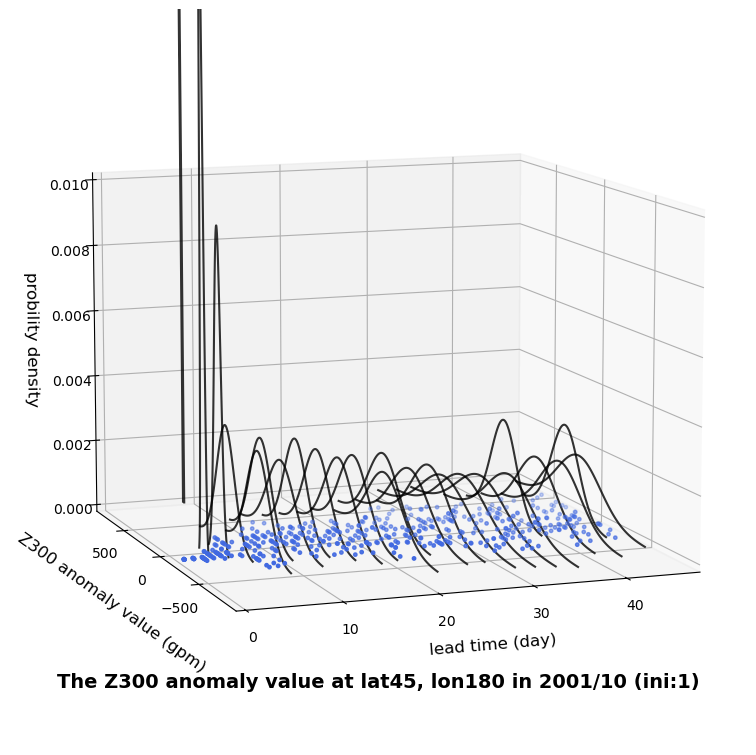

In [9]:
# plot Guassian pdf
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(0, dim[0]):
    plt.scatter(t_, z_mb_anm_6d[i, 0, 0, :, 30, 120], s=6, zorder=1, c='royalblue')

for i in range(0, dim[3], 2):
    y = np.linspace(fig1_mean[i] - 3*fig1_std[i], fig1_mean[i] + 3*fig1_std[i], 100)
    z = norm.pdf(y, fig1_mean[i], fig1_std[i])
    x_vals = np.full_like(y, t_[i])
    ax.plot(x_vals, y, z, color='k', zorder=2, alpha=0.8)
ax.view_init(elev=10, azim=250)  # elev 控制上下角度，azim 控制水平角度
ax.set_xlabel('lead time (day)', labelpad=10, fontsize=12)
ax.set_ylabel('Z300 anomaly value (gpm)', labelpad=10, fontsize=12)
ax.set_zlabel('probility density', labelpad=10, fontsize=12)
ax.set_xlim(0, 47)
ax.set_zlim(0, 0.01)
ax.set_yticks([-500, 0, 500])
fig.suptitle("The Z300 anomaly value at lat45, lon180 in 2001/10 (ini:1)", y=0.11, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/work/Hyttttt/fig07/reforecast_01.png", dpi=200)
#plt.close()

In [10]:
# Consider latitude weights
wgt_lat = np.sqrt(np.cos(np.deg2rad(lat_)))  # (61,)
wgt_lat_mb = np.broadcast_to(wgt_lat.reshape(1, dim[4], 1), 
                             (dim[0]*dim[1]*dim[2]*dim[3], dim[4], dim[5]))  # (10*20*42*47, 61, 240)

z_mb_anm_3d = z_mb_anm.reshape(dim[0]*dim[1]*dim[2]*dim[3], dim[4], dim[5])  # (10*20*42*47, 61, 240)
z_mb_anm_3d_wgt = z_mb_anm_3d * wgt_lat_mb
z_mb_anm_2d_wgt = z_mb_anm_3d_wgt.reshape(dim[0]*dim[1]*dim[2]*dim[3], dim[4]*dim[5])  # (394800, 14640)
# time scale:    394800 = 10 * 20 * 42 * 47
# spatial scale: 14640  = 61 * 240

In [11]:
# Set PCA function
nPC = 10
pca1 = PCA(n_components=nPC, random_state=67)

In [12]:
# Put "z_mb_anm_2d_wgt" into PCA
pcs = pca1.fit_transform(z_mb_anm_2d_wgt)  # (394800, 10)

In [13]:
EOFs = pca1.components_.T  # (14640, 10)

In [14]:
# Normalize each PCs
PCs_norm = (pcs - pcs.mean(axis=0))/pcs.std(axis=0, ddof=1)

In [15]:
# Calculate Var(PC)
PCs_norm_5d  = PCs_norm.reshape(dim[0], dim[1], dim[2], dim[3], nPC)  # (nmb, yr, ini, ld, nPC)
PCs_norm_var = PCs_norm_5d.var(axis=0, ddof=1)                        # (yr, ini, ld, nPC)
PCs_norm_var_3d  = PCs_norm_var.reshape(dim[1]*dim[2], dim[3], nPC)   # (yr * ini, ld, nPC)
PCs_norm_avg_var = PCs_norm_var_3d.mean(axis=0)                       # (ld, nPC)
PCs_norm_avg_var_max = PCs_norm_avg_var[-7:, :].mean(axis=0)          # (nPC,)

In [16]:
# Plot 10 Var(PC) and their climatological variance
fig, axs = plt.subplots(2, 5, figsize=(20, 10), sharey=True)
axs = axs.flatten()

for j in range(nPC):
    ax = axs[j]
    ax.plot(t_, PCs_norm_avg_var[:, j], c="k", linewidth=2, label="average")
    ax.axhline(
        y=PCs_norm_avg_var_max[j],
        xmin=-1,
        xmax=47,
        c="r",
        linestyle="--",
        linewidth=3,
        label="var maximum:%.2e" % PCs_norm_avg_var_max[j],
    )
    ax.legend(loc="lower right")
    ax.set_xlim(-1, 47)
    ax.set_xlabel("Time (day)", fontsize=12)
    ax.set_title(f"Var(PC{j+1})", fontsize=15)

fig.suptitle(
    "Variance (averaged over years and initial times) of normalized PCs", fontsize=20
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("/work/Hyttttt/fig07/NH_winter_norm_Var_10PC.png", dpi=200)
plt.close()

In [17]:
# Plot 10 Var(PC) together
BLUES = plt.cm.Blues(np.linspace(0.9, 0.3, 10))
REDS  = plt.cm.Reds(np.linspace(0.9, 0.3, 10))
plt.figure(figsize=(8, 6))
for j in range(nPC):
    plt.plot(t_, PCs_norm_avg_var[:, j], label=f"PC{j+1}", c=BLUES[j], zorder=1)
    plt.axhline(y=PCs_norm_avg_var_max[j], xmin=-1, xmax=47, c=REDS[j], zorder=0,
                linestyle="--")
plt.legend(loc="lower right")
plt.xlim(-1, 47)
plt.xlabel("lead time (day)", labelpad=10, fontsize=12)
plt.ylabel("Var", labelpad=10, fontsize=12)
plt.title(
    "Variance (averaged over years and initial times) of normalized PCs", fontsize=14, fontweight='bold'
)
#plt.savefig("/work/Hyttttt/fig07/NH_winter_norm_Var_10PC_1plot.png", dpi=200)
plt.close()

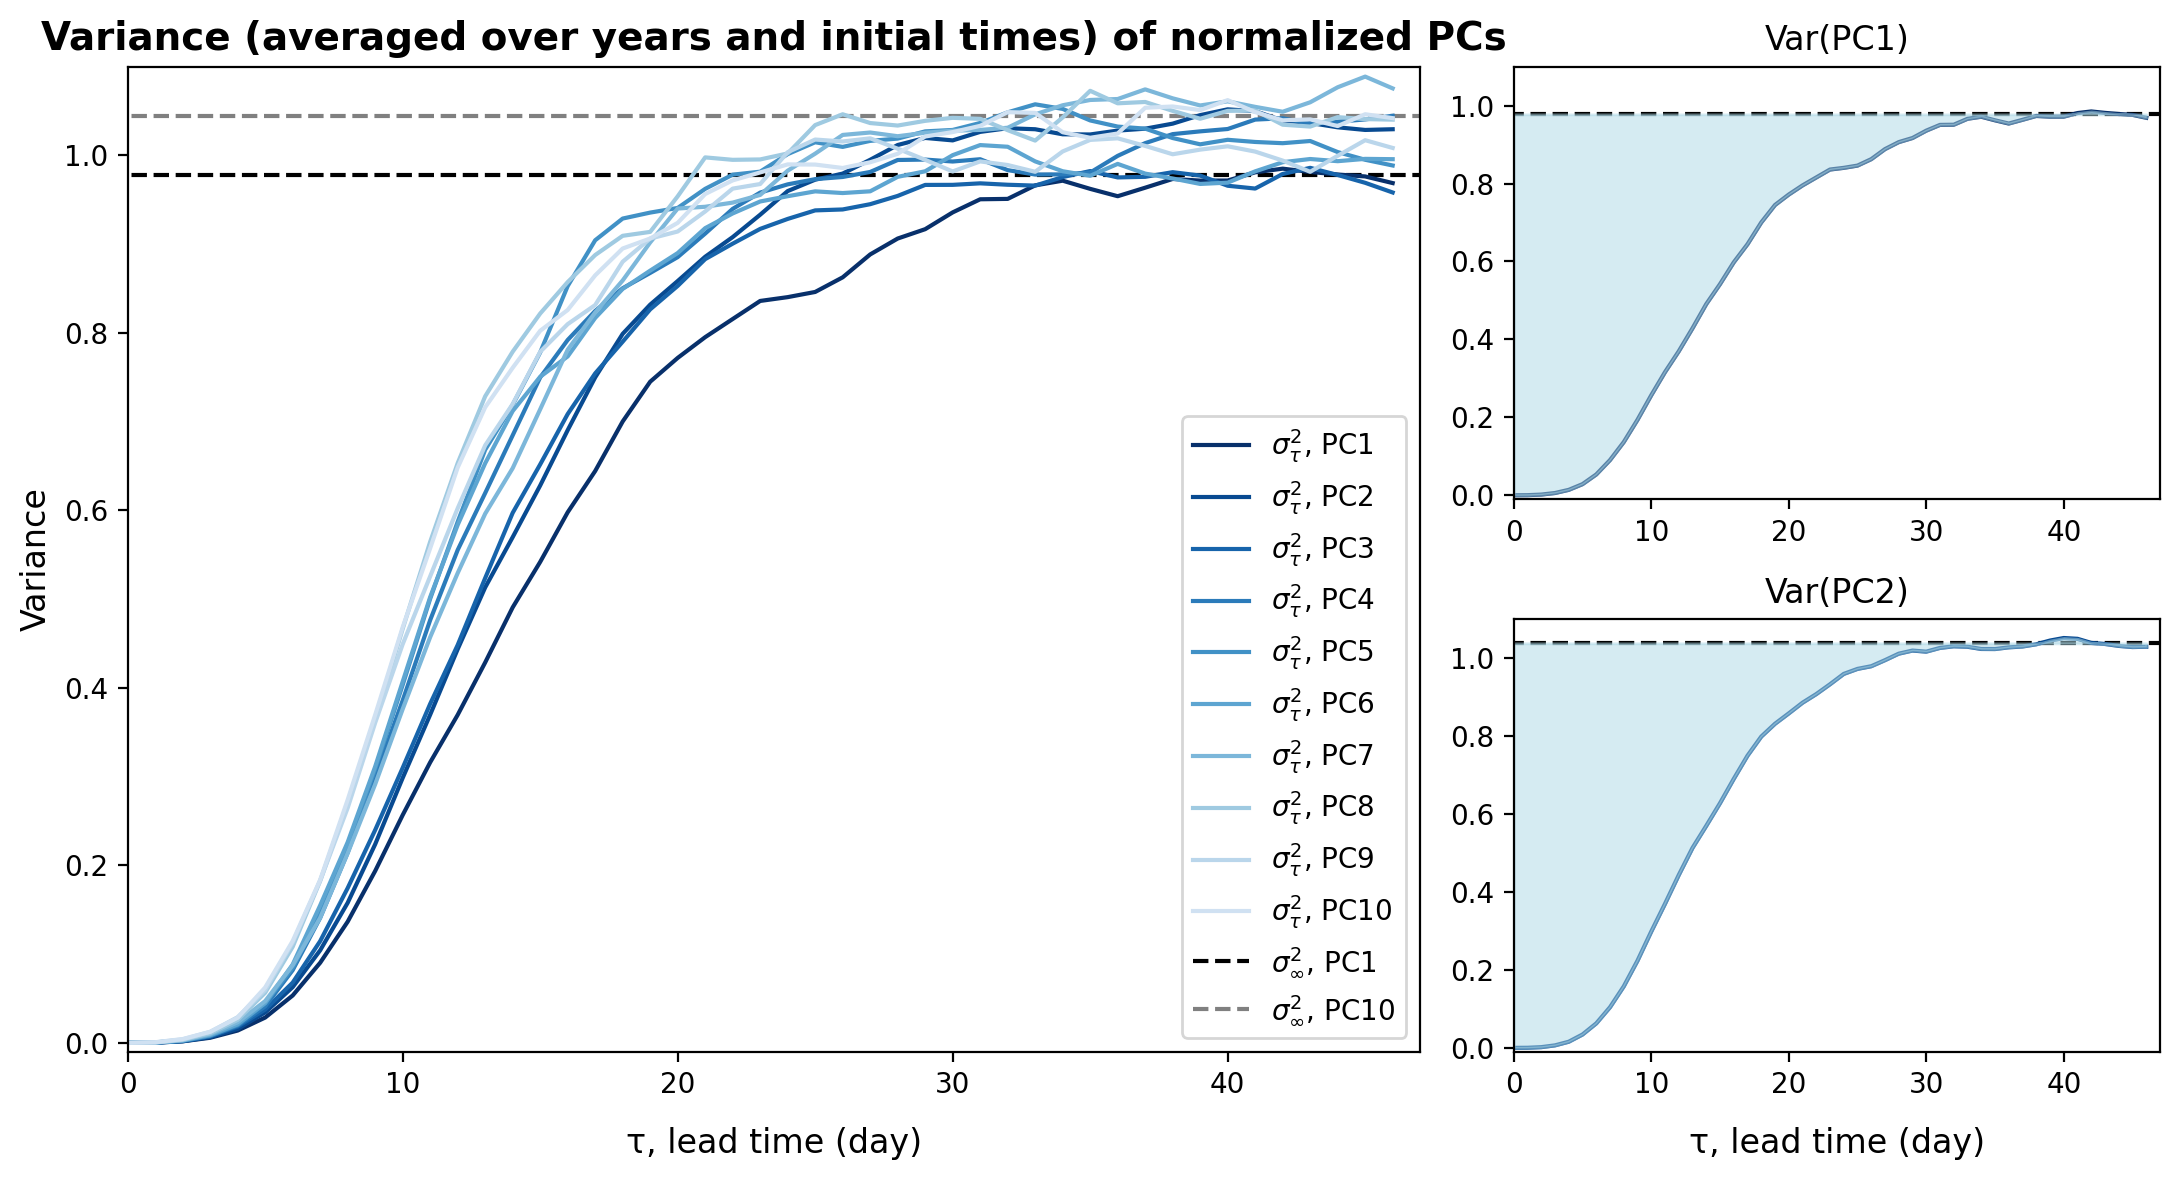

In [18]:
# Plot 10 Var(PC) together
BLUES = plt.cm.Blues(np.concatenate((np.array([1, 0.9]), np.linspace(0.8, 0.2, 8))))
fig = plt.figure(figsize=(11, 6), dpi=200)
gs = GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[:, 0])
for j in range(nPC):
    ax1.plot(t_, PCs_norm_avg_var[:, j], label=f"$σ^{2}_{{τ}}$, PC{j+1}", c=BLUES[j], zorder=1)
ax1.axhline(y=PCs_norm_avg_var_max[0], xmin=-1, xmax=47, c='k', zorder=0, linestyle="--", label=r'$σ^{2}_{∞}$, PC1')
ax1.axhline(y=PCs_norm_avg_var_max[-1], xmin=-1, xmax=47, c='gray', zorder=0, linestyle="--", label=r'$σ^{2}_{∞}$, PC10')
plt.legend(loc="lower right")
ax1.set(xlim=(0, 47), ylim=(-0.01, 1.1))
ax1.set_xlabel("τ, lead time (day)", labelpad=10, fontsize=12)
ax1.set_ylabel("Variance", fontsize=12)
ax1.set_title("Variance (averaged over years and initial times) of normalized PCs", fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_, PCs_norm_avg_var[:, 0], label="PC1", c=BLUES[0], zorder=1)
ax2.axhline(y=PCs_norm_avg_var_max[0], xmin=-1, xmax=47, c='k', zorder=0, linestyle="--")
ax2.fill_between(t_, PCs_norm_avg_var[:, 0], PCs_norm_avg_var_max[0], color="lightblue", alpha = 0.5)
ax2.set(xlim=(0, 47), ylim=(-0.01, 1.1))
ax2.set_title("Var(PC1)", fontsize=12)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_, PCs_norm_avg_var[:, 1], label="PC2", c=BLUES[1], zorder=1)
ax3.axhline(y=PCs_norm_avg_var_max[1], xmin=-1, xmax=47, c='k', zorder=0, linestyle="--")
ax3.fill_between(t_, PCs_norm_avg_var[:, 1], PCs_norm_avg_var_max[1], color="lightblue", alpha = 0.5)
ax3.set(xlim=(0, 47), ylim=(-0.01, 1.1))
ax3.set_title("Var(PC2)", fontsize=12)
ax3.set_xlabel("τ, lead time (day)", labelpad=10, fontsize=12)
plt.tight_layout()
plt.savefig("/work/Hyttttt/fig07/reforecast_02.png", dpi=200)

In [19]:
# Plot 10 Cumulated Var(PC) together
PCs_norm_avg_cum_var = np.cumsum(PCs_norm_avg_var, axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
for j in range(nPC):
    ax.plot(t_, PCs_norm_avg_cum_var[:, j], label=f"PC{j+1}", alpha=0.7)
ax.legend(loc="lower right")
ax.set_xlim(-1, 47)
ax.set_xlabel("lead time (day)", fontsize=12)
ax.set_title(
    "Cumulated Variance (averaged over years and initial times) of normalized PCs",
    fontsize=13,
)

x1, x2, y1, y2 = 35, 40, 21, 31
rect = Rectangle(
    (x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor="k", facecolor="none"
)
ax.add_patch(rect)

ax_inset = fig.add_axes([0.2, 0.42, 0.21, 0.42])  # [left, bottom, width, height]
for j in range(nPC):
    ax_inset.plot(t_, PCs_norm_avg_cum_var[:, j], label=f"PC{j+1}", alpha=0.7)

ax_inset.set_xlim(x1, x2)
ax_inset.set_ylim(y1, y2)
ax_inset.set_xticks(np.arange(x1, x2+1, 5))
ax_inset.set_yticks(np.arange(y1, y2+1, 5))

#plt.savefig("/work/Hyttttt/fig07/NH_winter_norm_cum_Var_10PC_1plot.png", dpi=200)
plt.savefig("/work/Hyttttt/fig07/fig03-1.png", dpi=200)
plt.close()

In [20]:
# Calculate Sigma_tau, Sigma_inf
# PCs_norm_5d  # (nmb, yr, ini, ld, nPC)
Sigma_tau   = np.zeros((dim[3], nPC, nPC))                  # (ld, (nPC, nPC))
X_cov       = np.zeros((dim[1], dim[2], dim[3], nPC, nPC))  # (nyr * ini, ld, (nPC, nPC))

for ld in range(dim[3]):
    for yr in range(dim[1]):
        for ini in range(dim[2]):
            X = PCs_norm_5d[:, yr, ini, ld, :]  # (nmb, nPCs)
            X_cen = X - X.mean(axis=0)
            X_cov[yr, ini, ld, :, :] = np.dot(X_cen.T, X_cen) / (X.shape[0] - 1)
    Sigma_tau[ld, :, :] = X_cov[:, :, ld, :, :].mean(axis=0).mean(axis=0)

# Sigma_inf is calculated by the last 7 days
Sigma_inf = Sigma_tau[-7:, :, :].mean(axis=0)

In [21]:
A = np.zeros((nPC, nPC))
for ld in range(dim[3]):
    A += 2 * np.dot(np.linalg.inv(Sigma_inf), Sigma_inf - Sigma_tau[ld, :, :])  # (nPC, nPC)

In [22]:
# The resonable value of diagonal A
for i in range(10):
    print(i,((PCs_norm_avg_var_max[i] - PCs_norm_avg_var[:, i])/PCs_norm_avg_var_max[i]).sum()*2)

0 31.520284163544623
1 29.30551861896099
2 27.249959274788257
3 27.680877097969393
4 23.55991579621033
5 25.125911224574242
6 27.71947149802892
7 23.951638564607492
8 24.02334028770461
9 25.060266860851183


Text(0.5, 1.0, '(NH, winter) A')

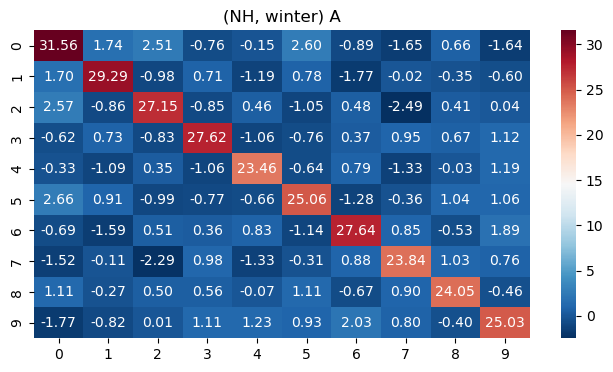

In [23]:
# Plot A
plt.figure(figsize=(8, 4))
sns.heatmap(A, annot=True, fmt=".2f", cmap="RdBu_r", cbar=True)
plt.title("(NH, winter) A")
#plt.savefig("/work/Hyttttt/fig06/NH_winter_A.png", dpi=200)

In [24]:
# Calculate APT & q
egvl, egvt = np.linalg.eig(A)

sort_id = np.argsort(egvl)[::-1]
egvl_sort = egvl[sort_id]
egvt_sort = egvt[:, sort_id]

lamb = egvl_sort[0]
q = egvt_sort[:, 0]
p = np.dot(Sigma_inf, q)

# Find 2nd max
lamb2 = egvl_sort[1]
q2 = egvt_sort[:, 1]

# Find 3rd max
q3 = egvt_sort[:, 2]

In [25]:
# Cumulative Variance
exp_var = pca1.explained_variance_ratio_*100
cum_var = np.cumsum(exp_var)
d = {
    "exp_var(%)": exp_var.round(3),
    "cum_var(%)": cum_var.round(3)
}
df = pd.DataFrame(data=d, index=[f"PC{i+1}" for i in range(len(egvl))])
df

,exp_var(%),cum_var(%)
PC1,7.843,7.843
PC2,7.107,14.951
PC3,5.807,20.757
PC4,4.972,25.730
PC5,4.870,30.599
PC6,4.468,35.067
PC7,4.243,39.310
PC8,3.643,42.953
PC9,3.325,46.277
PC10,2.984,49.261


In [26]:
p = np.dot(Sigma_inf, q)
p2 = np.dot(Sigma_inf, q2)

In [27]:
d = {
    "egvl_sorted": egvl_sort.round(3),
    "MP1 wgt": p.round(3),
    "MP2 wgt": p2.round(3),
    #"MP3 wgt": q3.round(3),
}
df = pd.DataFrame(data=d, index=[f"{i+1}" for i in range(len(egvl))])
df

,egvl_sorted,MP1 wgt,MP2 wgt
1,35.250,-0.760,-0.178
2,31.498,-0.322,0.636
3,28.507,-0.224,-0.526
4,27.154,0.153,0.325
5,26.770,0.052,-0.264
6,25.347,-0.236,0.129
7,24.195,0.287,-0.371
8,23.212,0.205,0.244
9,22.411,-0.058,0.039
10,20.362,0.209,-0.071


In [28]:
lamb

35.25032698934411

In [29]:
# Calculate 3 most predictable modes
MP_EOF = np.dot(EOFs, p).reshape(61, 240)
MP2_EOF = np.dot(EOFs, p2).reshape(61, 240)
MP3_EOF = np.dot(EOFs, q3).reshape(61, 240)

In [ ]:
EOF1 = EOFs[:, 0].reshape(61, 240)
EOF2 = EOFs[:, 1].reshape(61, 240)
fig, axs = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.EqualEarth(central_longitude=200)})

clevs = np.linspace(-0.035, 0.035, 15)
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=":")
axs[0].contourf(lon_, lat_, EOF1, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[0].set_title("EOF1")

axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=":")
fill = axs[1].contourf(lon_, lat_, EOF2, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[1].set_title("EOF2")

fig.colorbar(fill, ax=axs, orientation="horizontal", pad=0.05, shrink=0.9)
plt.savefig("/work/Hyttttt/fig07/reforecast_04.png", dpi=300)

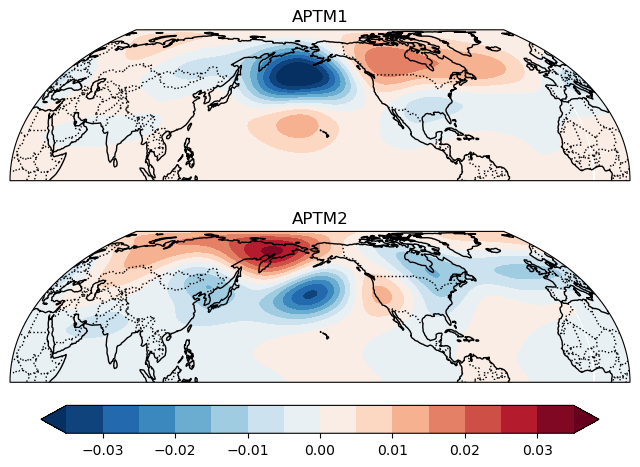

In [31]:
# plot the most predictable mode
fig, axs = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.EqualEarth(central_longitude=200)})

clevs = np.linspace(-0.035, 0.035, 15)
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=":")
axs[0].contourf(lon_, lat_, MP_EOF, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[0].set_title("APTM1")

axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=":")
fill = axs[1].contourf(lon_, lat_, MP2_EOF, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[1].set_title("APTM2")

fig.colorbar(fill, ax=axs, orientation="horizontal", pad=0.05, shrink=0.9)
plt.savefig("/work/Hyttttt/fig07/reforecast_03.png", dpi=300)
#plt.savefig(f"/work/Hyttttt/fig07/NH_winter_MP_EOF_nPC{nPC}.png", dpi=300)
#plt.close()

## Make a sample of 150 days of reanalysis data

In [32]:
# load reanalysis data # Year:1979~2021
nc = Dataset("/work/DATA/Reanalysis/ERA5/z/z250_1980.nc")
lat_ana = np.flip(nc.variables["lat"][179:])  # (181,) ### Note that 順序與預報場相反
lon_ana = nc.variables["lon"][:]  # (576,)

dim1 = [42, 150, 360, 576]

In [33]:
# load reanalysis data
z_ana = np.zeros((dim1[0], dim1[1], dim1[2], dim1[3]))  # (yr, day, lat, lon)
for yr in range(dim1[0]):
    nc1 = Dataset(f"/work/DATA/Reanalysis/ERA5/z/z250_{yr_ra1[yr]}.nc")
    nc2 = Dataset(f"/work/DATA/Reanalysis/ERA5/z/z250_{yr_ra2[yr]}.nc")
    z_ana[yr, :91, :, :] = nc1.variables["z"][-91:, ::-1, :]
    z_ana[yr, 91:, :, :] = nc2.variables["z"][:59, ::-1, :]
    nc1.close()
nc2.close()
z_ana = z_ana[:, :, :181, :]  # (42, 150, 181, 576)

In [34]:
# Calculate the anomaly
z_ana_ano = z_ana - z_ana.mean(axis=0)  # (yr, day, lat, lon)
z_ana_ano_3d = z_ana_ano.reshape(dim1[0] * dim1[1], 181, dim1[3])

In [35]:
def interpolate_data(data, lat_ana, lon_ana, lat_, lon_):
    result = np.zeros((data.shape[0], len(lat_), len(lon_)))

    # TARGET grid coordinates
    target_grid = np.array([(lat, lon) for lat in lat_ for lon in lon_])

    # Start interpolation
    for i in range(data.shape[0]):
        # ORIGINAL grid coordinates
        interpolator = RegularGridInterpolator(
            (lat_ana, lon_ana),
            data[i, :, :],
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        result[i, :, :] = interpolator(target_grid).reshape(len(lat_), len(lon_))

    return result

In [36]:
new_z_ana_ano_3d = interpolate_data(z_ana_ano_3d, lat_ana, lon_ana, lat_, lon_)
new_z_ana_ano_4d = new_z_ana_ano_3d.reshape(dim1[0], dim1[1], dim[4], dim[5])

In [37]:
new_z_ana_ano_2d = new_z_ana_ano_3d.reshape(dim1[0]*dim1[1], dim[4]*dim[5])
APTM1 = MP_EOF.reshape(dim[4]*dim[5], 1)
APTM2 = MP2_EOF.reshape(dim[4]*dim[5], 1)

y1_t_2d = np.dot(new_z_ana_ano_2d, APTM1).flatten().reshape(dim1[0], dim1[1])  # (yr, day)
y2_t_2d = np.dot(new_z_ana_ano_2d, APTM2).flatten().reshape(dim1[0], dim1[1])  # (yr, day)

In [38]:
# Normalize each row
y1_t_norm_2d = (y1_t_2d - y1_t_2d.mean(axis=1, keepdims=True))/y1_t_2d.std(axis=1, ddof=1, keepdims=True)
y2_t_norm_2d = (y2_t_2d - y2_t_2d.mean(axis=1, keepdims=True))/y2_t_2d.std(axis=1, ddof=1, keepdims=True)

In [39]:
# Calculate average power spectrum
def calc_avg_power_spectrum(signal):
    nyr = signal.shape[0]
    T = signal.shape[1]
    max_wb = signal.shape[1] // 2
    power = np.zeros((nyr, max_wb))
    for yr in range(nyr):
        ck = fft(signal[yr, :])
        # Not including wavenumber 0
        sp = 2 * ck[1:max_wb + 1] * ck[1:max_wb + 1].conj() / T**2
        power[yr, :] = sp / sp.sum() # retaining the total variance in 1
    avg_power = power.mean(axis=0)
    return avg_power

# ck[0] denote wavenumber0
# ck[i] = ck[-i]* , * means conjugate

In [40]:
power1_yr_avg = calc_avg_power_spectrum(y1_t_norm_2d)
power2_yr_avg = calc_avg_power_spectrum(y2_t_norm_2d)
cycle = 150 / np.arange(1, 76)  # day

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [41]:
# Plot avg power of APTM1
plt.figure(figsize=(10, 4))
plt.plot(cycle, power1_yr_avg, c='royalblue')
plt.xlabel("Cycle (day)")
plt.xscale("log")
plt.ylabel("Explained Variance")
plt.title("42-year average power of APTM1, Area below line=%.2f"%np.trapz(power1_yr_avg, dx=1))
#plt.savefig("/work/Hyttttt/fig07/Power_APTM1_42yrAVG.png", dpi=200)
plt.close()

In [42]:
# the significant cycle of APTM1
print('power=%.3f, cycle=%.2f day'%(power1_yr_avg[2], cycle[2]))

power=0.114, cycle=50.00 day


In [43]:
# Plot avg power of APTM2
plt.figure(figsize=(10, 4))
plt.plot(cycle, power2_yr_avg, c='royalblue')
plt.xlabel("Cycle (day)")
plt.xscale("log")
plt.ylabel("Explained Variance")
plt.title("42-year average power of APTM2, Area below line=%.2f"%np.trapz(power2_yr_avg, dx=1))
#plt.savefig("/work/Hyttttt/fig07/Power_APTM2_42yrAVG.png", dpi=200)
plt.close()

In [44]:
# Sampling & Trials Settings
n_tr = 200          # number of trials
n_x = int(1e5)    # length of x_array

# Sampling settings
l_sp = 150  # days
n_sp = 42  # number of sampling

# self corrcoef of PC1
a1 = np.corrcoef(y1_t_norm_2d.flatten()[:-1], y1_t_norm_2d.flatten()[1:])[0, 1]
power1_sp_avg = np.zeros((n_tr, 75))

# self corrcoef of PC2
a2 = np.corrcoef(y2_t_norm_2d.flatten()[:-1], y2_t_norm_2d.flatten()[1:])[0, 1]
power2_sp_avg = np.zeros((n_tr, 75))
a2

0.9449182250815363

In [45]:
# Sampling & Trials for APTM1
np.random.seed(95)
o_sd1 = np.random.randint(1, 1e4, size=n_tr, dtype=int)  # the order of random seed

for sd in range(n_tr): # trials
    np.random.seed(o_sd1[sd])
    e1 = np.random.normal(0, np.sqrt(1 - a1**2), size = n_x)  # noise for recurrence relation
    e2 = np.random.randint(1, n_x - l_sp, size=n_sp)          # random sampling for fft 
    
    # built the recurrence relation
    x_arr = np.zeros(n_x)
    x_arr[0] = y1_t_norm_2d.flatten()[0]
    for t in range(n_x-1):
        x_arr[t+1] = a1 * x_arr[t] + e1[t]
       
    # random sampling for fft
    segments = np.array([x_arr[i:i + l_sp] for i in e2])
    
    power1_sp_avg[sd, :] = calc_avg_power_spectrum(segments)
    '''
    if sd < 10:
        # plot red noises in each trials
        plt.subplots(figsize=(10, 4))
        plt.plot(np.arange(1, 1000+1), x_arr[:1000])
        for i in range(n_sp):
            plt.axvspan(selected_indices[i], selected_indices[i]+150, color='red', alpha=0.1)
        plt.xlim(-1, 1000)
        plt.xlabel('days')
        plt.title(f'red noise from t=0 to t=1000, trial={sd}')
        plt.savefig(f"/work/Hyttttt/fig07/RedNoise_trial{sd}.png", dpi=200)
        plt.close()
    '''

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [46]:
# Sampling & Trials for APTM2
np.random.seed(195)
o_sd2 = np.random.randint(1, 1e4, size=n_tr, dtype=int)  # the order of random seed

for sd in range(n_tr): # trials
    np.random.seed(o_sd2[sd])
    e1 = np.random.normal(0, np.sqrt(1 - a1**2), size = n_x)  # noise for recurrence relation
    e2 = np.random.randint(1, n_x - l_sp, size=n_sp)          # random sampling for fft 
    
    # built the recurrence relation
    x_arr = np.zeros(n_x)
    x_arr[0] = y2_t_norm_2d.flatten()[0]
    for t in range(n_x-1):
        x_arr[t+1] = a1 * x_arr[t] + e1[t]
       
    # random sampling for fft
    segments = np.array([x_arr[i:i + l_sp] for i in e2])
    
    power2_sp_avg[sd, :] = calc_avg_power_spectrum(segments)

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [47]:
# Plot power of PC1 in each trial
plt.figure(figsize=(10, 4))
for i in range(n_tr):
    plt.plot(cycle, power1_sp_avg[i, :], c='k', alpha=0.5)
plt.xlabel('Cycle (day)')
plt.xscale('log')
plt.ylabel('Explained Variance')
plt.title(f'{n_tr} trials, PC1')
plt.savefig(f"/work/Hyttttt/fig07/org_power_PC1.png", dpi=200)
plt.close()

In [48]:
# 200 trials and 42 samples per trial
# ensemble mean and confidence interval
alpha = 0.05
power1_tr_mean  = power1_sp_avg.mean(axis = 0)
power1_tr_std   = power1_sp_avg.std(axis = 0)
power1_tr_conf_h = stats.norm.interval(1-alpha, power1_tr_mean, power1_tr_std)[1]
power1_tr_conf_l = stats.norm.interval(1-alpha, power1_tr_mean, power1_tr_std)[0]

power2_tr_mean  = power2_sp_avg.mean(axis = 0)
power2_tr_std   = power2_sp_avg.std(axis = 0)
power2_tr_conf_h = stats.norm.interval(1-alpha, power2_tr_mean, power2_tr_std)[1]
power2_tr_conf_l = stats.norm.interval(1-alpha, power2_tr_mean, power2_tr_std)[0]

In [49]:
# Rescaling the power spectrum of red noise
power1_tr_mean   /= power1_tr_mean.sum()
power1_tr_conf_h /= power1_tr_mean.sum()
power1_tr_conf_l /= power1_tr_mean.sum()

power2_tr_mean   /= power2_tr_mean.sum()
power2_tr_conf_h /= power2_tr_mean.sum()
power2_tr_conf_l /= power2_tr_mean.sum()

In [50]:
def theoretical_red_noise_power_spectrum(signal, cycle):
    a    = np.corrcoef(signal[:-1], signal[1:])[0, 1]
    max_wb = len(signal) // 2
    freq = 1 / cycle
    sp   = (1 - a**2) / (1 + a**2 - 2 * a * np.cos(2 * np.pi * freq))
    return freq, sp

In [51]:
# Calculate theoretical power spectrum of red noise
theo_freq1, theo_power1 = theoretical_red_noise_power_spectrum(y1_t_norm_2d.flatten(), cycle)
theo_power1 /= theo_power1.sum()

theo_freq2, theo_power2 = theoretical_red_noise_power_spectrum(y2_t_norm_2d.flatten(), cycle)
theo_power2 /= theo_power2.sum()

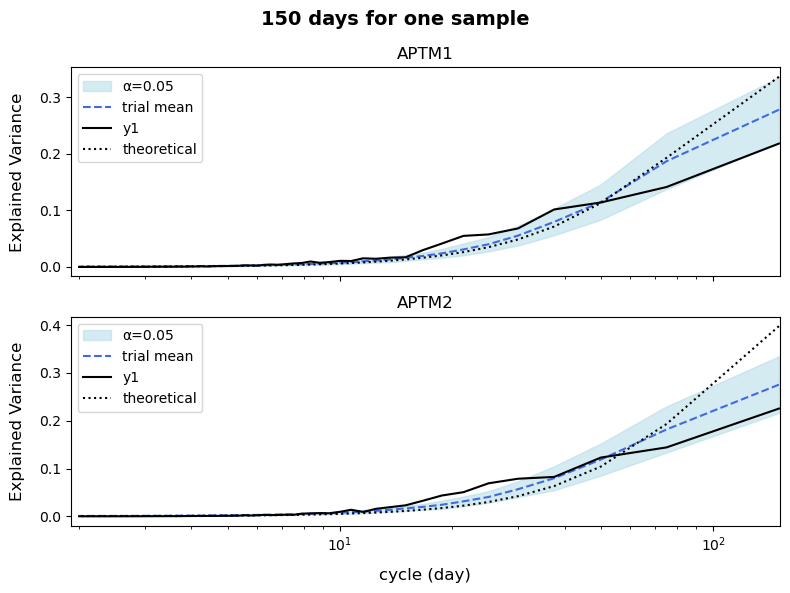

In [52]:
# Plot the confidence interval
# 150 days for a sample
# APTM1 vs ATPM2
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].fill_between(cycle, power1_tr_conf_l, power1_tr_conf_h, color="lightblue", alpha = 0.5, label=f'α={alpha}')
axs[0].plot(cycle, power1_tr_mean, color = "royalblue", linestyle = "--", label = "trial mean")
axs[0].plot(cycle, power1_yr_avg, c='k', label='y1')
axs[0].plot(cycle, theo_power1, c='k', linestyle=':', label='theoretical')
axs[0].legend(loc='upper left')
axs[0].set_xscale('log')
axs[0].set_xlim(1.9, 151)
axs[0].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[0].set_title('APTM1')

axs[1].fill_between(cycle, power2_tr_conf_l, power2_tr_conf_h, color="lightblue", alpha = 0.5, label=f'α={alpha}')
axs[1].plot(cycle, power2_tr_mean, color = "royalblue", linestyle = "--", label = "trial mean")
axs[1].plot(cycle, power2_yr_avg, c='k', label='y1')
axs[1].plot(cycle, theo_power2, c='k', linestyle=':', label='theoretical')
axs[1].legend(loc='upper left')
axs[1].set_xlabel('cycle (day)', labelpad=10, fontsize=12)
axs[1].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[1].set_title('APTM2')

plt.suptitle('150 days for one sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"/work/Hyttttt/fig07/reanalysis_01.png", dpi=200)
#plt.savefig(f"/work/Hyttttt/fig07/conf_power_PC1.png", dpi=200)
#plt.close()

## Make a sample of 2 years of reanalysis data

In [53]:
dim2 = [43, 365, 360, 576]
l_sp2 = int(dim2[1]*2)    # length of a sample
n_sp2 = dim2[0]           # numbers of sample

In [54]:
# load reanalysis data
z_ana2 = np.zeros((dim2[0], dim2[1], dim2[2], dim2[3]))  # (yr, day, lat, lon)
for yr in range(dim2[0]):
    nc = Dataset(f"/work/DATA/Reanalysis/ERA5/z/z250_{yr_ra[yr]}.nc")
    z_ana2[yr, :, :, :] = nc.variables["z"][:365, ::-1, :]
nc.close()
z_ana2 = z_ana2[:, :, :181, :]  # (43, 365, 181, 576)

In [55]:
# Calculate the anomaly
z_ana_ano2 = z_ana2 - z_ana2.mean(axis=0)  # (yr, day, lat, lon)
z_ana_ano2_3d = z_ana_ano2.reshape(dim2[0] * dim2[1], 181, dim2[3])

In [56]:
new_z_ana_ano2_3d = interpolate_data(z_ana_ano2_3d, lat_ana, lon_ana, lat_, lon_)

In [57]:
new_z_ana_ano2_2d = new_z_ana_ano2_3d.reshape(dim2[0]*dim2[1], dim[4]*dim[5])

y1_t2_2d = np.dot(new_z_ana_ano2_2d, APTM1).flatten().reshape(dim2[0], dim2[1])  # (yr, day)
y2_t2_2d = np.dot(new_z_ana_ano2_2d, APTM2).flatten().reshape(dim2[0], dim2[1])  # (yr, day)

In [58]:
# Normalize each row
y1_t2_norm_2d = (y1_t2_2d - y1_t2_2d.mean(axis=1, keepdims=True))/y1_t2_2d.std(axis=1, ddof=1, keepdims=True)
y2_t2_norm_2d = (y2_t2_2d - y2_t2_2d.mean(axis=1, keepdims=True))/y2_t2_2d.std(axis=1, ddof=1, keepdims=True)

# Make a sample of 2 years of reanalysis data
cycle2 = l_sp2 / np.arange(1, l_sp2//2+1)  # day
y1_t_norm_2d_2yr = np.hstack((y1_t2_norm_2d[:-1, :], y1_t2_norm_2d[1:, :]))
y2_t_norm_2d_2yr = np.hstack((y2_t2_norm_2d[:-1, :], y2_t2_norm_2d[1:, :]))

In [59]:
power1_yr_avg2 = calc_avg_power_spectrum(y1_t_norm_2d_2yr)
power2_yr_avg2 = calc_avg_power_spectrum(y2_t_norm_2d_2yr)

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [60]:
# self corrcoef of PC1_2yr
a3 = np.corrcoef(y1_t2_norm_2d.flatten()[:-1], y1_t2_norm_2d.flatten()[1:])[0, 1]
power1_sp_avg2 = np.zeros((n_tr, 365))

# self corrcoef of PC2_2yr
a4 = np.corrcoef(y2_t2_norm_2d.flatten()[:-1], y2_t2_norm_2d.flatten()[1:])[0, 1]
power2_sp_avg2 = np.zeros((n_tr, 365))

In [61]:
# Sampling & Trials  for APTM1_2yr
np.random.seed(95)
o_sd1 = np.random.randint(1, 1e4, size=n_tr, dtype=int)  # the order of random seed

for sd in range(n_tr): # trials
    np.random.seed(o_sd1[sd])
    e1 = np.random.normal(0, np.sqrt(1 - a1**2), size = n_x)    # noise for recurrence relation
    e2 = np.random.randint(1, n_x - l_sp2, size=n_sp2)          # random sampling for fft 
    
    # built the recurrence relation
    x_arr = np.zeros(n_x)
    x_arr[0] = y1_t_norm_2d.flatten()[0]
    for t in range(n_x-1):
        x_arr[t+1] = a1 * x_arr[t] + e1[t]
       
    # random sampling for fft
    segments = np.array([x_arr[i:i + l_sp2] for i in e2])
    
    power1_sp_avg2[sd, :] = calc_avg_power_spectrum(segments)

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [62]:
# Sampling & Trials  for APTM2_2yr
np.random.seed(195)
o_sd1 = np.random.randint(1, 1e4, size=n_tr, dtype=int)  # the order of random seed

for sd in range(n_tr): # trials
    np.random.seed(o_sd1[sd])
    e1 = np.random.normal(0, np.sqrt(1 - a1**2), size = n_x)    # noise for recurrence relation
    e2 = np.random.randint(1, n_x - l_sp2, size=n_sp2)          # random sampling for fft 
    
    # built the recurrence relation
    x_arr = np.zeros(n_x)
    x_arr[0] = y2_t_norm_2d.flatten()[0]
    for t in range(n_x-1):
        x_arr[t+1] = a1 * x_arr[t] + e1[t]
       
    # random sampling for fft
    segments = np.array([x_arr[i:i + l_sp2] for i in e2])
    
    power2_sp_avg2[sd, :] = calc_avg_power_spectrum(segments)

/tmp/ipykernel_848543/2947415254.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  power[yr, :] = sp / sp.sum() # retaining the total variance in 1


In [63]:
# 200 trials and 43 samples per trial
# ensemble mean and confidence interval
power1_tr_2yr_mean  = power1_sp_avg2.mean(axis = 0)
power1_tr_2yr_std   = power1_sp_avg2.std(axis = 0)
power1_tr_2yr_conf_h = stats.norm.interval(1-alpha, power1_tr_2yr_mean, power1_tr_2yr_std)[1]
power1_tr_2yr_conf_l = stats.norm.interval(1-alpha, power1_tr_2yr_mean, power1_tr_2yr_std)[0]

power2_tr_2yr_mean  = power2_sp_avg2.mean(axis = 0)
power2_tr_2yr_std   = power2_sp_avg2.std(axis = 0)
power2_tr_2yr_conf_h = stats.norm.interval(1-alpha, power2_tr_2yr_mean, power2_tr_2yr_std)[1]
power2_tr_2yr_conf_l = stats.norm.interval(1-alpha, power2_tr_2yr_mean, power2_tr_2yr_std)[0]

In [64]:
# Rescaling the power spectrum of red noise
power1_tr_2yr_mean   /= power1_tr_2yr_mean.sum()
power1_tr_2yr_conf_h /= power1_tr_2yr_mean.sum()
power1_tr_2yr_conf_l /= power1_tr_2yr_mean.sum()

power2_tr_2yr_mean   /= power2_tr_2yr_mean.sum()
power2_tr_2yr_conf_h /= power2_tr_2yr_mean.sum()
power2_tr_2yr_conf_l /= power2_tr_2yr_mean.sum()

In [65]:
# Calculate theoretical power spectrum of red noise
theo_freq3, theo_power3 = theoretical_red_noise_power_spectrum(y1_t2_norm_2d.flatten(), cycle2)
theo_power3 /= theo_power3.sum()

theo_freq4, theo_power4 = theoretical_red_noise_power_spectrum(y2_t2_norm_2d.flatten(), cycle2)
theo_power4 /= theo_power4.sum()

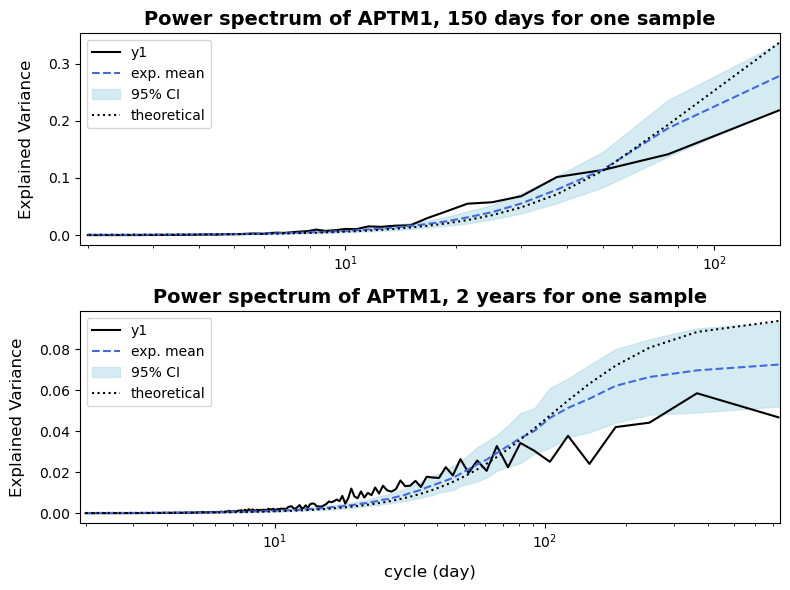

In [66]:
# Plot the confidence interval
# APTM1
# 150 days vs 2 years for a sample
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(cycle, power1_yr_avg, c='k', label='y1')
axs[0].plot(cycle, power1_tr_mean, color = "royalblue", linestyle = "--", label = "exp. mean")
axs[0].fill_between(cycle, power1_tr_conf_l, power1_tr_conf_h, color="lightblue", alpha = 0.5, label='95% CI')
axs[0].plot(cycle, theo_power1, c='k', linestyle=':', label='theoretical')
axs[0].legend(loc='upper left')
axs[0].set_xscale('log')
axs[0].set_xlim(1.9, 151)
axs[0].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[0].set_title('Power spectrum of APTM1, 150 days for one sample', fontsize=14, fontweight='bold')

axs[1].plot(cycle2, power1_yr_avg2, c='k', label='y1')
axs[1].plot(cycle2, power1_tr_2yr_mean, color = "royalblue", linestyle = "--", label = "exp. mean")
axs[1].fill_between(cycle2, power1_tr_2yr_conf_l, power1_tr_2yr_conf_h, color="lightblue", alpha = 0.5, label='95% CI')
axs[1].plot(cycle2, theo_power3, c='k', linestyle=':', label='theoretical')
axs[1].legend(loc='upper left')
axs[1].set_xscale('log')
axs[1].set_xlim(1.9, 740)
axs[1].set_xlabel('cycle (day)', labelpad=10, fontsize=12)
axs[1].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[1].set_title('Power spectrum of APTM1, 2 years for one sample', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"/work/Hyttttt/fig07/reanalysis_02.png", dpi=200)
#plt.savefig(f"/work/Hyttttt/fig07/conf_power_PC1.png", dpi=200)
#plt.close()

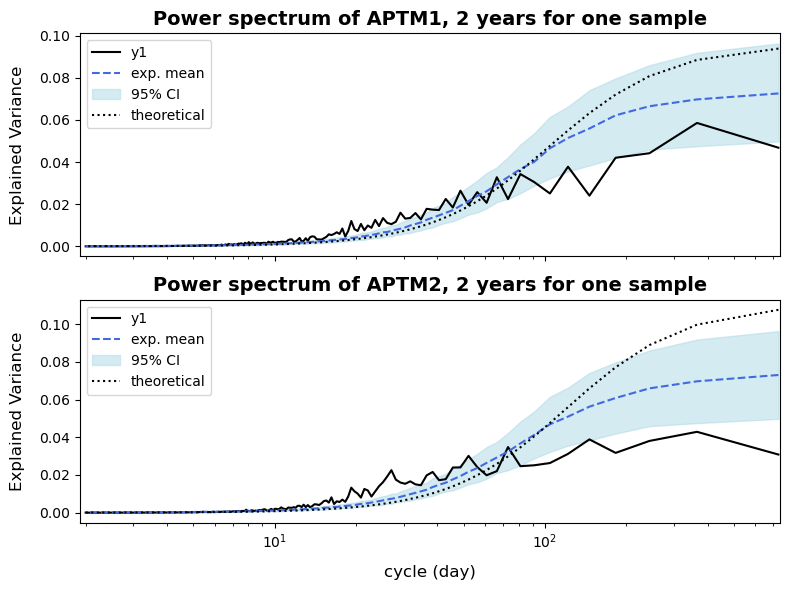

In [67]:
# Plot the confidence interval
# 2 years for a sample
# APTM1 vs APTM2
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(cycle2, power1_yr_avg2, c='k', label='y1')
axs[0].plot(cycle2, power1_tr_2yr_mean, color = "royalblue", linestyle = "--", label = "exp. mean")
axs[0].fill_between(cycle2, power2_tr_2yr_conf_l, power2_tr_2yr_conf_h, color="lightblue", alpha = 0.5, label='95% CI')
axs[0].plot(cycle2, theo_power3, c='k', linestyle=':', label='theoretical')
axs[0].legend(loc='upper left')
axs[0].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[0].set_title('Power spectrum of APTM1, 2 years for one sample', fontsize=14, fontweight='bold')

axs[1].plot(cycle2, power2_yr_avg2, c='k', label='y1')
axs[1].plot(cycle2, power2_tr_2yr_mean, color = "royalblue", linestyle = "--", label = "exp. mean")
axs[1].fill_between(cycle2, power2_tr_2yr_conf_l, power2_tr_2yr_conf_h, color="lightblue", alpha = 0.5, label='95% CI')
axs[1].plot(cycle2, theo_power4, c='k', linestyle=':', label='theoretical')
axs[1].legend(loc='upper left')
axs[1].set_xscale('log')
axs[1].set_xlim(1.9, 740)
axs[1].set_xlabel('cycle (day)', labelpad=10, fontsize=12)
axs[1].set_ylabel('Explained Variance', labelpad=10, fontsize=12)
axs[1].set_title('Power spectrum of APTM2, 2 years for one sample', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"/work/Hyttttt/fig07/reanalysis_03.png", dpi=200)
#plt.close()

## Satellite data

In [68]:
# load satellite data
nc = Dataset("/work/DATA/Satellite/OLR/olr_anomaly.nc")
lat_OLR = nc.variables["lat"][180:]  # (180,)
lon_OLR = nc.variables["lon"][:]     # (576,)
dim3 = [len(lat_OLR), len(lon_OLR)]
OLR = np.zeros((dim1[0], dim1[1], dim3[0], dim3[1]))
for i in range(dim1[0]):
    OLR[i, :, :, :] = nc.variables["olr"][274+365*i:274+365*i+150, 180:, :] #(42, 180, 576)

In [69]:
# Do linear regression on APTM1
y = OLR.reshape(dim1[0]*dim1[1], dim3[0]*dim3[1])
x = y1_t_norm_2d.reshape(dim1[0]*dim1[1], 1)
xtx = np.dot(x.T, x)
theta = (np.dot(x.T, y)/xtx).reshape(dim3[0], dim3[1])

# Do linear regression on APTM2
x2 = y2_t_norm_2d.reshape(dim1[0]*dim1[1], 1)
xt2x = np.dot(x2.T, x2)
theta2 = (np.dot(x2.T, y)/xt2x).reshape(dim3[0], dim3[1])

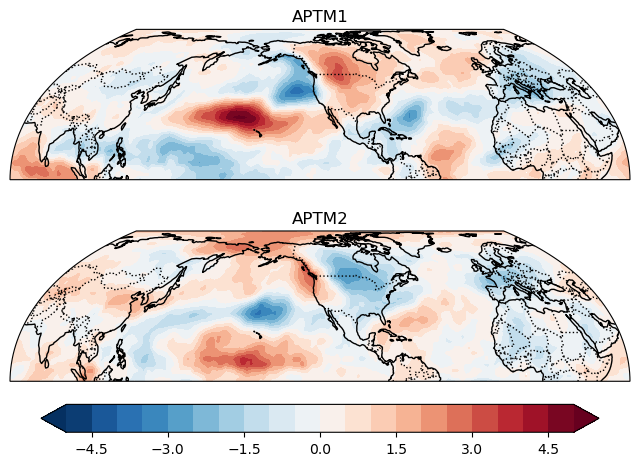

In [70]:
# Plot teleconnection
# plot the most predictable mode
fig, axs = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.EqualEarth(central_longitude=240)})

clevs = np.linspace(-5, 5, 21)
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=":")
fill1 = axs[0].contourf(lon_OLR, lat_OLR, theta, cmap="RdBu_r", levels=clevs,
                        transform=ccrs.PlateCarree(), extend="both")
axs[0].set_title("APTM1")

axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=":")
axs[1].contourf(lon_OLR, lat_OLR, theta2, cmap="RdBu_r", levels=clevs,
                transform=ccrs.PlateCarree(), extend="both")
axs[1].set_title("APTM2")

fig.colorbar(fill1, ax=axs, orientation="horizontal", pad=0.05, shrink=0.9)
plt.savefig(f"/work/Hyttttt/fig07/teleconnection.png", dpi=300)

In [71]:
# Do linear regression on APTM1 use package 
# OLR (yr, day, lat, lon)
# y1_t_norm_2d (yr, day)
olr = OLR.reshape(dim1[0]*dim1[1], dim3[0]*dim3[1])
y1  = y1_t_norm_2d.flatten()
y2  = y2_t_norm_2d.flatten()

a = np.zeros(dim3[0]*dim3[1])   # slope
p = np.zeros(dim3[0]*dim3[1])   # p-value
SE = np.zeros(dim3[0]*dim3[1])  # standard error of slope
a2 = np.zeros(dim3[0]*dim3[1])
p2 = np.zeros(dim3[0]*dim3[1])
SE2 = np.zeros(dim3[0]*dim3[1])

In [72]:
for QQ in range(dim3[0]*dim3[1]):
    a[QQ],  b, r,  p[QQ], SE[QQ]  = stats.linregress(y1, olr[:, QQ])
    a2[QQ], b, r, p2[QQ], SE2[QQ] = stats.linregress(y2, olr[:, QQ])

In [73]:
p[p > 0.01] = np.nan
p2[p2 > 0.01] = np.nan

a_2d = a.reshape(dim3[0], dim3[1])
p_2d = p.reshape(dim3[0], dim3[1])[4:-20, :][::15, ::12]
a2_2d = a2.reshape(dim3[0], dim3[1])
p2_2d = p2.reshape(dim3[0], dim3[1])[4:-20, :][::15, ::12]
llon_OLR, llat_OLR = np.meshgrid(lon_OLR[::12], lat_OLR[4:-20][::15])

non_nan_indices  = ~np.isnan(p_2d)
non_nan_indices2 = ~np.isnan(p2_2d)

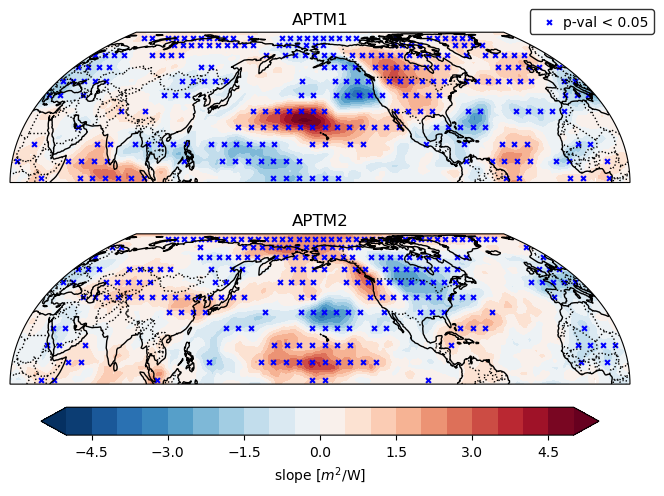

In [74]:
# Plot teleconnection
# plot the most predictable mode
fig, axs = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.EqualEarth(central_longitude=200)})

clevs = np.linspace(-5, 5, 21)
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=":")
fill1 = axs[0].contourf(lon_OLR, lat_OLR, a_2d, cmap="RdBu_r", levels=clevs,
                        transform=ccrs.PlateCarree(), extend="both")
axs[0].scatter(llon_OLR[non_nan_indices],llat_OLR[non_nan_indices],
               c='b', marker='x', transform=ccrs.PlateCarree(), s=12, label='p-val < 0.05')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.05, 1.2), handletextpad=0.01, edgecolor='k')
axs[0].set_title("APTM1")

axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=":")
axs[1].contourf(lon_OLR, lat_OLR, a2_2d, cmap="RdBu_r", levels=clevs,
                transform=ccrs.PlateCarree(), extend="both")
axs[1].scatter(llon_OLR[non_nan_indices2],llat_OLR[non_nan_indices2],
               c='b', marker="x", transform=ccrs.PlateCarree(), s=12)
axs[1].set_title("APTM2")

cbar = fig.colorbar(fill1, ax=axs, orientation="horizontal", pad=0.05, shrink=0.9)
cbar.set_label(r'slope [${m^2}$/W]')
plt.savefig(f"/work/Hyttttt/fig07/satellite_01.png", dpi=300)

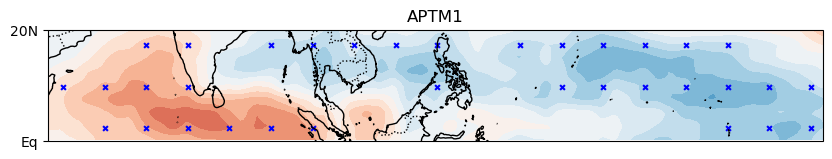

In [75]:
fig, ax = plt.subplots(figsize=(10, 3), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=80)})

clevs = np.linspace(-5, 5, 21)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
fill1 = ax.contourf(lon_OLR, lat_OLR, a_2d, cmap="RdBu_r", levels=clevs,
                        transform=ccrs.PlateCarree(), extend="both")
ax.scatter(llon_OLR[non_nan_indices],llat_OLR[non_nan_indices],
               c='b', marker='x', transform=ccrs.PlateCarree(), s=12, label='p-val < 0.05')
ax.set_extent([50, 190, 0, 20], crs=ccrs.PlateCarree())
ax.set_yticks([0, 20], crs=ccrs.PlateCarree())
ax.set_yticklabels(['Eq', '20N'])
ax.set_title('APTM1')
plt.savefig(f"/work/Hyttttt/fig07/satellite_02.png", dpi=300)